# Ciência da Computação — Soluções em Energias Renováveis e Sustentáveis
### Atividade prática com datasets de energia — Orange Data Mining, Python e Pandas

Este notebook contém a **Etapa B (Python / Pandas)** dos seis datasets da atividade, incluindo o Dataset 1 (já preparado anteriormente) para manter tudo organizado em um único arquivo.

A **Etapa A (Orange Data Mining)** foi realizada previamente para cada dataset: carregamento, inspeção, seleção de atributos, verificação de valores ausentes, amostragem e exportação em CSV. Os arquivos `.csv` usados abaixo já correspondem às amostras exportadas do Orange (por isso trazem duas linhas extras de metadados logo após o cabeçalho — o tipo de cada atributo — que são ignoradas no carregamento com `skiprows=[1, 2]`).

Nenhuma etapa de aprendizado de máquina foi utilizada — o foco é preparação, manipulação e interpretação dos dados.

# **Imagem padrão de todos os arquivos csv configurados no orange**
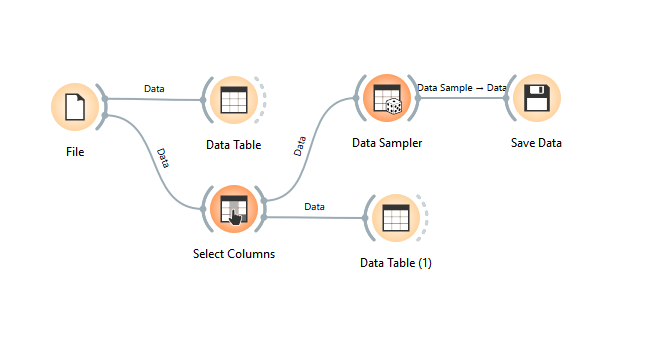

In [55]:
import pandas as pd
pd.set_option('display.max_columns', None)

---
## Dataset 1 — Appliances Energy Prediction (UCI)

### Situação
Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

### Etapa A — Orange Data Mining (resumo)
- Arquivo `energydata_complete.csv` carregado no widget **File**.
- **Select Columns** manteve `Appliances`, `lights` e os atributos de temperatura/umidade de três ambientes (`T1/RH_1`, `T2/RH_2`, `T3/RH_3`).
- Verificação de valores ausentes: nenhum encontrado (dataset originalmente completo).
- **Data Sampler** gerou uma amostra aleatória de **10%** dos registros (o dataset original tem 19.735 linhas; a amostra final tem 1.974, o que confirma o percentual).
- Amostra exportada como `dataset_ex_1.csv`, utilizada abaixo.

### Etapa B — Python / Pandas

In [ ]:
# 1. Carregamento e inspeção inicial
d1 = pd.read_csv('dataset_ex_1.csv', skiprows=[1, 2])
d1.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,2016-03-14 01:40:00,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,2016-01-30 20:00:00,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,2016-03-15 03:00:00,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,2016-04-20 10:10:00,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,2016-03-13 08:10:00,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [ ]:
print("Dimensões (linhas, colunas):", d1.shape)
d1.info()

Dimensões (linhas, colunas): (1974, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1974 non-null   object 
 1   Appliances  1974 non-null   int64  
 2   lights      1974 non-null   int64  
 3   T1          1974 non-null   float64
 4   RH_1        1974 non-null   float64
 5   T2          1974 non-null   float64
 6   RH_2        1974 non-null   float64
 7   T3          1974 non-null   float64
 8   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 138.9+ KB


In [ ]:
d1.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


**2. Renomeando o consumo e simplificando os nomes dos atributos ambientais**

In [ ]:
d1 = d1.rename(columns={
    'Appliances': 'Consumo_Eletrodomesticos',
    'T1': 'Temp_Cozinha',
    'RH_1': 'Umid_Cozinha',
    'T2': 'Temp_Sala',
    'RH_2': 'Umid_Sala',
    'T3': 'Temp_Lavanderia',
    'RH_3': 'Umid_Lavanderia'
})
d1.head()

,date,Consumo_Eletrodomesticos,lights,Temp_Cozinha,Umid_Cozinha,Temp_Sala,Umid_Sala,Temp_Lavanderia,Umid_Lavanderia
0,2016-03-14 01:40:00,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,2016-01-30 20:00:00,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,2016-03-15 03:00:00,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,2016-04-20 10:10:00,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,2016-03-13 08:10:00,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


**3. Maior consumo de eletrodomésticos registrado na amostra**

In [ ]:
maximo_consumo = d1['Consumo_Eletrodomesticos'].max()
maximo_consumo

770

**4. Limiar de 70% do máximo e filtragem dos registros de alto consumo**

In [ ]:
limiar_70 = 0.70 * maximo_consumo
df_alto_consumo = d1[d1['Consumo_Eletrodomesticos'] > limiar_70]
print(f"Limiar (70% do máximo): {limiar_70:.2f} Wh")
df_alto_consumo.shape

Limiar (70% do máximo): 539.00 Wh


(22, 9)

**5. Quantidade e percentual de registros de alto consumo**

In [ ]:
qtd_alto = len(df_alto_consumo)
pct_alto = qtd_alto / len(d1) * 100
print(f"Registros de alto consumo: {qtd_alto}")
print(f"Percentual da amostra: {pct_alto:.2f}%")

Registros de alto consumo: 22
Percentual da amostra: 1.11%


**6. Temperatura média na cozinha (T1) e segundo DataFrame com os dois critérios**

In [ ]:
media_temp_cozinha = d1['Temp_Cozinha'].mean()

df_alto_consumo_temp = d1[
    (d1['Consumo_Eletrodomesticos'] > limiar_70) &
    (d1['Temp_Cozinha'] > media_temp_cozinha)
]

qtd_alto_temp = len(df_alto_consumo_temp)
pct_alto_temp = qtd_alto_temp / len(d1) * 100

print(f"Temperatura média na cozinha (T1): {media_temp_cozinha:.2f} °C")
print(f"Registros com consumo alto E temperatura acima da média: {qtd_alto_temp}")
print(f"Percentual da amostra: {pct_alto_temp:.2f}%")

Temperatura média na cozinha (T1): 21.66 °C
Registros com consumo alto E temperatura acima da média: 8
Percentual da amostra: 0.41%


**7. Comparação e interpretação**

Isolando apenas o consumo elevado (acima de 70% do máximo), **22 registros (1.11% da amostra)** foram selecionados. Ao exigir também que a temperatura da cozinha (T1) estivesse acima da média, o conjunto caiu para **8 registros (0.41%)** — menos da metade.

Isso indica que boa parte dos picos de consumo de eletrodomésticos **não** ocorre necessariamente em momentos de temperatura interna elevada: o padrão de uso dos aparelhos (horário, quantidade de equipamentos ligados) parece pesar mais do que a temperatura ambiente da cozinha nesses picos específicos. A temperatura funciona aqui como um segundo filtro que reduz o conjunto, evidenciando que "alto consumo" e "ambiente mais quente" só coincidem em parte dos casos.

---
## Dataset 2 — Steel Industry Energy Consumption (UCI)

### Situação
A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.

### Etapa A — Orange Data Mining (resumo)
- Arquivo carregado no **File** e inspecionado no **Data Table**.
- **Select Columns** manteve `Usage_kWh`, as variáveis de potência reativa, os fatores de potência, `WeekStatus`, `Day_of_week` e `Load_Type`.
- No Data Table observou-se que `Load_Type` assume os valores *Light_Load*, *Medium_Load* e *Maximum_Load*, e `WeekStatus` assume *Weekday*/*Weekend*.
- Nenhum valor ausente encontrado.
- **Data Sampler** gerou uma amostra aleatória de **20%** (dataset original com 35.040 linhas; amostra final com 3.504, confirmando o percentual).
- Amostra exportada como `Steel_industry_data.csv`.

### Etapa B — Python / Pandas

In [ ]:
# 1. Carregamento e renomeação
d2 = pd.read_csv('Steel_industry_data.csv', skiprows=[1, 2])
d2 = d2.rename(columns={
    'Usage_kWh': 'Consumo_kWh',
    'Lagging_Current_Power_Factor': 'FP_Atrasado',
    'Leading_Current_Power_Factor': 'FP_Adiantado'
})
d2.head()

,date,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),FP_Atrasado,FP_Adiantado,WeekStatus,Day_of_week,Load_Type
0,29/04/2018 07:15,2.88,3.82,0.0,0.00,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,0.03,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,0.06,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,0.00,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,0.03,94.19,100.00,Weekday,Friday,Medium_Load


**2. Inspeção inicial**

In [ ]:
print("Dimensões (linhas, colunas):", d2.shape)
d2.info()

Dimensões (linhas, colunas): (3504, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3504 entries, 0 to 3503
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  3504 non-null   object 
 1   Consumo_kWh                           3504 non-null   float64
 2   Lagging_Current_Reactive.Power_kVarh  3504 non-null   float64
 3   Leading_Current_Reactive_Power_kVarh  3504 non-null   float64
 4   CO2(tCO2)                             3504 non-null   float64
 5   FP_Atrasado                           3504 non-null   float64
 6   FP_Adiantado                          3504 non-null   float64
 7   WeekStatus                            3504 non-null   object 
 8   Day_of_week                           3504 non-null   object 
 9   Load_Type                             3504 non-null   object 
dtypes: float64(6), object(4)
memory usage: 273.9

In [ ]:
d2.describe()

,Consumo_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),FP_Atrasado,FP_Adiantado
count,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000
mean,27.246701,13.087491,3.802309,0.011507,80.254241,84.463142
std,33.352371,16.399117,7.383096,0.016160,19.084149,30.387569
min,2.450000,0.000000,0.000000,0.000000,39.100000,12.790000
25%,3.200000,2.590000,0.000000,0.000000,62.797500,99.800000
50%,4.555000,5.040000,0.000000,0.000000,87.675000,100.000000
75%,52.030000,22.280000,1.690000,0.020000,98.480000,100.000000
max,153.140000,87.700000,27.650000,0.070000,100.000000,100.000000


**3. Maior consumo registrado e limiar de 75%**

In [ ]:
maximo_consumo2 = d2['Consumo_kWh'].max()
limiar_75 = 0.75 * maximo_consumo2
print(f"Consumo máximo: {maximo_consumo2:.2f} kWh")
print(f"Limiar (75% do máximo): {limiar_75:.2f} kWh")

Consumo máximo: 153.14 kWh
Limiar (75% do máximo): 114.85 kWh


**4. DataFrame com consumo acima do limiar — quantidade e percentual**

In [ ]:
df_alto_consumo2 = d2[d2['Consumo_kWh'] > limiar_75]
qtd_alto2 = len(df_alto_consumo2)
pct_alto2 = qtd_alto2 / len(d2) * 100
print(f"Registros de alto consumo: {qtd_alto2}")
print(f"Percentual da amostra: {pct_alto2:.2f}%")

Registros de alto consumo: 65
Percentual da amostra: 1.86%


**5. Quantos desses registros pertencem à categoria Maximum_Load**

In [ ]:
qtd_maxload = (df_alto_consumo2['Load_Type'] == 'Maximum_Load').sum()
pct_maxload = qtd_maxload / qtd_alto2 * 100
print(f"Registros de alto consumo classificados como Maximum_Load: {qtd_maxload} de {qtd_alto2} ({pct_maxload:.1f}%)")

Registros de alto consumo classificados como Maximum_Load: 32 de 65 (49.2%)


**6. Observando o fator de potência atrasado (FP_Atrasado) para escolher um limite de valores baixos**

In [ ]:
d2['FP_Atrasado'].describe()

,FP_Atrasado
count,3504.000000
mean,80.254241
std,19.084149
min,39.100000
25%,62.797500
50%,87.675000
75%,98.480000
max,100.000000


O fator de potência atrasado varia de aproximadamente 39 a 100, com mediana em torno de 88. Um valor abaixo de **90** já representa um fator de potência abaixo do ideal (a maioria das indústrias busca manter o fator de potência acima de 92–95 para evitar penalidades). Esse será o limite usado abaixo.

**7. DataFrame com consumo elevado E fator de potência abaixo do limite escolhido**

In [ ]:
limite_fp = 90

df_alto_fp_baixo = d2[
    (d2['Consumo_kWh'] > limiar_75) &
    (d2['FP_Atrasado'] < limite_fp)
]

qtd_fp_baixo = len(df_alto_fp_baixo)
pct_fp_baixo = qtd_fp_baixo / len(d2) * 100
print(f"Registros com consumo elevado e fator de potência abaixo de {limite_fp}: {qtd_fp_baixo}")
print(f"Percentual da amostra: {pct_fp_baixo:.2f}%")

Registros com consumo elevado e fator de potência abaixo de 90: 22
Percentual da amostra: 0.63%


**8. Interpretação**

Do total de **65 registros de alto consumo (1.86% da amostra)**, **32 (quase metade)** já ocorrem em carga classificada como *Maximum_Load* — o que é esperado, já que consumo elevado tende a coincidir com a categoria de carga máxima definida pela própria indústria.

Ao cruzar consumo elevado com fator de potência atrasado abaixo de 90, o conjunto cai para apenas **22 registros (0.63% da amostra)**. Esse subconjunto merece atenção especial da equipe de energia porque reúne simultaneamente **alta demanda** e **baixa eficiência elétrica**: fator de potência baixo nesses momentos de pico aumenta a corrente reativa na rede, eleva perdas e pode gerar penalidades tarifárias — é justamente a combinação mais custosa para a operação, e não apenas o consumo alto isoladamente.

---
## Dataset 3 — Power Consumption of Tetouan City (UCI)

### Situação
Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.

### Etapa A — Orange Data Mining (resumo)
- Dataset carregado e inspecionado no **Data Table**.
- **Select Columns** manteve as três variáveis de consumo (`Zone 1/2/3 Power Consumption`), `Temperature`, `Humidity` e `Wind Speed`.
- Observou-se que as três zonas possuem escalas de consumo diferentes entre si.
- Nenhum valor ausente encontrado.
- **Data Sampler** gerou uma amostra aleatória de **15%** (dataset original com 52.416 linhas; amostra final com 7.863, confirmando o percentual).
- Amostra exportada como `Tetuan_City_power_consumption.csv`.

### Etapa B — Python / Pandas

In [ ]:
# 1. Carregamento e renomeação das zonas de consumo
d3 = pd.read_csv('Tetuan City power consumption.csv', skiprows=[1, 2])
d3 = d3.rename(columns={
    'Zone 1 Power Consumption': 'Consumo_Zona_1',
    'Zone 2  Power Consumption': 'Consumo_Zona_2',
    'Zone 3  Power Consumption': 'Consumo_Zona_3'
})
d3.head()

,DateTime,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,4/18/2017 16:20,22.76,29.73,0.085,32985.14532,19396.7,17623.3
1,12/27/2017 17:10,15.92,54.44,0.085,34737.64259,29803.0,14417.3
2,1/2/2017 11:20,15.08,57.23,0.076,27894.68354,20808.5,16458.8
3,3/19/2017 20:20,12.42,72.30,0.081,42476.93617,23634.1,25089.7
4,4/24/2017 5:50,14.58,80.60,0.080,21341.14101,12006.1,11531.6


In [ ]:
print("Dimensões (linhas, colunas):", d3.shape)
d3.describe()

Dimensões (linhas, colunas): (7863, 7)


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
count,7863.000000,7863.000000,7863.000000,7863.000000,7863.000000,7863.000000
mean,18.789376,68.400612,1.965602,32371.549651,21060.733609,17845.600069
std,5.864564,15.665773,2.350954,7134.686966,5202.357437,6573.203996
min,3.541000,13.340000,0.054000,14612.658230,9436.250000,6211.760000
25%,14.340000,58.485000,0.078000,26263.115455,17013.400000,13200.700000
50%,18.690000,70.000000,0.086000,32249.429660,20851.600000,16490.300000
75%,22.820000,81.500000,4.915000,37421.355555,24812.200000,21763.600000
max,39.600000,94.700000,6.325000,51571.498340,36437.200000,47441.700000


**2. Consumo máximo em cada zona**

In [ ]:
maximos_zonas = {
    'Consumo_Zona_1': d3['Consumo_Zona_1'].max(),
    'Consumo_Zona_2': d3['Consumo_Zona_2'].max(),
    'Consumo_Zona_3': d3['Consumo_Zona_3'].max()
}
maximos_zonas

{'Consumo_Zona_1': 51571.49834,
 'Consumo_Zona_2': 36437.2,
 'Consumo_Zona_3': 47441.7}

**3. Zona com o maior pico de consumo na amostra**

In [ ]:
zona_pico = max(maximos_zonas, key=maximos_zonas.get)
print(f"Zona com maior pico de consumo: {zona_pico} ({maximos_zonas[zona_pico]:.2f})")

Zona com maior pico de consumo: Consumo_Zona_1 (51571.50)


**4. Limiar de 70% do máximo da zona identificada e filtragem**

In [ ]:
limiar_zona = 0.70 * maximos_zonas[zona_pico]
df_alto_zona = d3[d3[zona_pico] > limiar_zona]
print(f"Limiar (70% do máximo de {zona_pico}): {limiar_zona:.2f}")
df_alto_zona.shape

Limiar (70% do máximo de Consumo_Zona_1): 36100.05


(2388, 7)

**5. Quantidade e percentual de registros acima do limiar**

In [ ]:
qtd_zona = len(df_alto_zona)
pct_zona = qtd_zona / len(d3) * 100
print(f"Registros de alto consumo em {zona_pico}: {qtd_zona}")
print(f"Percentual da amostra: {pct_zona:.2f}%")

Registros de alto consumo em Consumo_Zona_1: 2388
Percentual da amostra: 30.37%


**6. Temperatura média e segundo DataFrame com os dois critérios**

In [ ]:
media_temp3 = d3['Temperature'].mean()

df_alto_zona_temp = d3[
    (d3[zona_pico] > limiar_zona) &
    (d3['Temperature'] > media_temp3)
]

qtd_zona_temp = len(df_alto_zona_temp)
pct_zona_temp = qtd_zona_temp / len(d3) * 100

print(f"Temperatura média: {media_temp3:.2f} °C")
print(f"Registros com consumo alto E temperatura acima da média: {qtd_zona_temp}")
print(f"Percentual da amostra: {pct_zona_temp:.2f}%")

Temperatura média: 18.79 °C
Registros com consumo alto E temperatura acima da média: 1597
Percentual da amostra: 20.31%


**7. Comparação e interpretação**

A **Zona 1** apresenta o maior pico de consumo entre as três zonas. Considerando apenas o consumo acima de 70% do seu próprio máximo, **2.388 registros (30.37% da amostra)** foram selecionados — uma parcela relevante, o que sugere que a Zona 1 passa uma fração considerável do tempo em regime de demanda elevada.

Ao adicionar a condição de temperatura acima da média, o conjunto caiu para **1.597 registros (20.31% da amostra)**. A redução (de ~30% para ~20%) mostra que existe uma associação real, mas não total, entre consumo elevado e temperaturas mais altas — parte dos picos de consumo na Zona 1 ocorre também em dias mais amenos, provavelmente ligados a outros fatores (horário comercial, uso simultâneo de equipamentos, dias específicos da semana) além da temperatura.

---
## Dataset 4 — Solar Power Generation Data (Kaggle)

### Situação
Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. O foco é o arquivo de geração da planta (`Plant_1_Generation_Data.csv`), sem junção com o arquivo de sensores.

### Etapa A — Orange Data Mining (resumo)
- Arquivo de geração da planta carregado no **File** e inspecionado no **Data Table**.
- **Select Columns** manteve `DATE_TIME`, `SOURCE_KEY`, `DC_POWER`, `AC_POWER`, `DAILY_YIELD` e `TOTAL_YIELD`.
- Observou-se grande quantidade de registros com potência igual a zero (período noturno, sem geração solar) e uma ampla faixa de valores em `AC_POWER` durante o dia.
- Nenhum valor ausente encontrado.
- **Data Sampler** gerou uma amostra aleatória de **20%** (dataset original com 68.778 linhas; amostra final com 13.756, confirmando o percentual).
- Amostra exportada como `Plant_1_Generation_Data.csv`.

### Etapa B — Python / Pandas

In [ ]:
# 1. Carregamento e renomeação
d4 = pd.read_csv('Plant_1_Generation_Data.csv', skiprows=[1, 2])
d4 = d4.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria'
})
d4.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
0,10-06-2020 19:00,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240508.000
1,28-05-2020 00:15,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206549.000
2,17-05-2020 15:15,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036055.000
3,01-06-2020 04:15,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308232.000
4,17-05-2020 09:00,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021701.375


In [ ]:
print("Dimensões (linhas, colunas):", d4.shape)
d4.info()

Dimensões (linhas, colunas): (13756, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13756 entries, 0 to 13755
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       13756 non-null  object 
 1   SOURCE_KEY      13756 non-null  object 
 2   Potencia_CC     13756 non-null  float64
 3   Potencia_CA     13756 non-null  float64
 4   Geracao_Diaria  13756 non-null  float64
 5   TOTAL_YIELD     13756 non-null  float64
dtypes: float64(4), object(2)
memory usage: 644.9+ KB


In [ ]:
d4.describe()

,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
count,13756.000000,13756.000000,13756.000000,1.375600e+04
mean,3135.848662,306.695495,3319.235216,6.978829e+06
std,4023.069619,393.124284,3142.249927,4.162164e+05
min,0.000000,0.000000,0.000000,6.183645e+06
25%,0.000000,0.000000,0.000000,6.509779e+06
50%,370.071500,35.771400,2730.425000,7.146218e+06
75%,6350.562500,622.065500,6293.782500,7.267996e+06
max,14416.100000,1405.590000,9163.000000,7.846821e+06


**2. Maior potência CA registrada**

In [ ]:
maxima_potencia_ca = d4['Potencia_CA'].max()
maxima_potencia_ca

1405.59

**3. Limiar de 70% da potência CA máxima e filtragem**

In [ ]:
limiar_ca = 0.70 * maxima_potencia_ca
df_alta_geracao = d4[d4['Potencia_CA'] > limiar_ca]

qtd_alta = len(df_alta_geracao)
pct_alta = qtd_alta / len(d4) * 100

print(f"Limiar (70% da potência CA máxima): {limiar_ca:.2f}")
print(f"Registros de alta geração: {qtd_alta}")
print(f"Percentual da amostra: {pct_alta:.2f}%")

Limiar (70% da potência CA máxima): 983.91
Registros de alta geração: 1185
Percentual da amostra: 8.61%


**4. Inversores mais frequentes nos registros de alta geração**

In [ ]:
df_alta_geracao['SOURCE_KEY'].value_counts()

,count
SOURCE_KEY,
adLQvlD726eNBSB,68
McdE0feGgRqW7Ca,65
ZnxXDlPa8U1GXgE,63
pkci93gMrogZuBj,62
ZoEaEvLYb1n2sOq,61
1IF53ai7Xc0U56Y,59
YxYtjZvoooNbGkE,58
sjndEbLyjtCKgGv,57
z9Y9gH1T5YWrNuG,56


**5. Interpretação**

Apenas **8.61% da amostra (1.185 registros)** corresponde a momentos de alta geração (acima de 70% da potência CA máxima) — coerente com o fato de a geração solar se concentrar em poucas horas do dia, com muitos registros noturnos em zero.

O inversor **`adLQvlD726eNBSB`** aparece com maior frequência nesse recorte (68 ocorrências), seguido de perto por outros dois ou três inversores com contagens próximas. Isso permite observar que a geração elevada não está concentrada em um único equipamento, mas distribuída de forma relativamente equilibrada entre os inversores da planta. **Não é possível concluir**, apenas com essa contagem, se algum inversor tem desempenho superior ou inferior — para isso seria necessário normalizar pela capacidade nominal de cada inversor e pelo tempo em que cada um esteve ativo, o que foge do escopo desta atividade.

---
## Dataset 5 — Wind & Solar Energy Production (Kaggle)

### Situação
Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

> **⚠️ Observação importante sobre o arquivo:** o arquivo enviado (`Energy_Production_Dataset.csv`) não possui colunas separadas de geração solar e geração eólica como o dataset "Wind & Solar Energy Production" original do Kaggle — ele traz apenas uma coluna única `Production`, junto com data, hora e estação do ano (`Season`). Para manter a lógica pedida pelo exercício (duas séries com escalas próprias, cada uma comparada ao seu próprio máximo), foi feita uma **adaptação**: os registros foram separados por estação do ano (**Verão** e **Inverno**) e cada subconjunto foi analisado com seu próprio limiar de 70%, no lugar de "solar" e "eólica". Se você tiver o arquivo correto do Kaggle com colunas de geração solar e eólica separadas, envie-o que o notebook é facilmente ajustado (basta trocar a etapa de separação por estação pela seleção direta das duas colunas de geração).

### Etapa A — Orange Data Mining (resumo)
- Dataset carregado e atributos temporais e de produção inspecionados.
- **Select Columns** manteve os atributos temporais (`Date`, `Start_Hour`, `End_Hour`, `Day_Name`, `Month_Name`, `Season`) e a variável de produção (`Production`).
- Valores mínimo e máximo de produção observados no Data Table.
- Nenhum valor ausente encontrado.
- **Data Sampler** gerou uma amostra aleatória de **20%** dos registros.
- Amostra exportada como `Energy_Production_Dataset.csv`.

### Etapa B — Python / Pandas

In [ ]:
# 1. Carregamento e renomeação
d5 = pd.read_csv('Energy Production Dataset.csv', skiprows=[1, 2])
d5 = d5.rename(columns={'Production': 'Geracao'})
d5.head()

,Date,Start_Hour,End_Hour,Day_of_Year,Day_Name,Month_Name,Season,Geracao
0,12/18/2022,21,22,352,Sunday,December,Winter,11400
1,1/29/2024,14,15,29,Monday,January,Winter,7917
2,8/1/2024,15,16,214,Thursday,August,Summer,8835
3,11/10/2020,1,2,315,Tuesday,November,Fall,989
4,12/19/2022,1,2,353,Monday,December,Winter,12526


In [ ]:
print("Dimensões (linhas, colunas):", d5.shape)
d5['Season'].value_counts()

Dimensões (linhas, colunas): (10373, 8)


,count
Season,
Spring,2686
Summer,2661
Fall,2627
Winter,2399


**2. Separando os dois subconjuntos (adaptação: Verão x Inverno no lugar de Solar x Eólica) e obtendo o máximo de cada um**

In [ ]:
geracao_grupo_a = d5[d5['Season'] == 'Summer']   # substitui 'Geração Solar'
geracao_grupo_b = d5[d5['Season'] == 'Winter']   # substitui 'Geração Eólica'

max_grupo_a = geracao_grupo_a['Geracao'].max()
max_grupo_b = geracao_grupo_b['Geracao'].max()

print(f"Máximo Grupo A (Verão): {max_grupo_a}")
print(f"Máximo Grupo B (Inverno): {max_grupo_b}")

Máximo Grupo A (Verão): 20359
Máximo Grupo B (Inverno): 22043


**3. Limiar de 70% do máximo de cada grupo, calculado separadamente**

In [ ]:
limiar_grupo_a = 0.70 * max_grupo_a
limiar_grupo_b = 0.70 * max_grupo_b

print(f"Limiar Grupo A (70% do máximo de Verão): {limiar_grupo_a:.2f}")
print(f"Limiar Grupo B (70% do máximo de Inverno): {limiar_grupo_b:.2f}")

Limiar Grupo A (70% do máximo de Verão): 14251.30
Limiar Grupo B (70% do máximo de Inverno): 15430.10


**4. DataFrames de alta geração para cada grupo**

In [ ]:
df_alta_grupo_a = geracao_grupo_a[geracao_grupo_a['Geracao'] > limiar_grupo_a]
df_alta_grupo_b = geracao_grupo_b[geracao_grupo_b['Geracao'] > limiar_grupo_b]

df_alta_grupo_a.shape, df_alta_grupo_b.shape

((20, 8), (173, 8))

**5. Quantidade e percentual de cada grupo**

In [ ]:
qtd_a = len(df_alta_grupo_a)
pct_a = qtd_a / len(geracao_grupo_a) * 100

qtd_b = len(df_alta_grupo_b)
pct_b = qtd_b / len(geracao_grupo_b) * 100

print(f"Grupo A (Verão): {qtd_a} registros de alta geração ({pct_a:.2f}% do grupo)")
print(f"Grupo B (Inverno): {qtd_b} registros de alta geração ({pct_b:.2f}% do grupo)")

Grupo A (Verão): 20 registros de alta geração (0.75% do grupo)
Grupo B (Inverno): 173 registros de alta geração (7.21% do grupo)


**6. Comparação entre os grupos**

O Grupo B (Inverno) apresenta uma frequência de alta geração muito maior em relação ao seu próprio máximo (**7.21%**) do que o Grupo A, Verão (**0.75%**) — quase 10 vezes mais. Isso mostra que, dentro dessa base de dados, os episódios de produção próxima do pico se concentram proporcionalmente mais no inverno.

**7. Por que não usar o mesmo valor numérico como limite para os dois grupos**

O máximo do Grupo A é 20.359 e o do Grupo B é 22.043 — próximos, mas os grupos têm distribuições diferentes. Se comparássemos por escalas totalmente distintas (como aconteceria de fato entre geração solar e eólica, cujas potências nominais e perfis de variação são muito diferentes), usar um único valor absoluto como limiar penalizaria a fonte de menor escala e nunca filtraria adequadamente a de maior escala. Calcular o limiar como percentual do próprio máximo de cada série garante que a comparação seja proporcional e justa entre fontes com magnitudes distintas — é exatamente por isso que o exercício pede que cada fonte seja avaliada em relação ao seu próprio valor máximo, e não a um valor fixo comum.

---
## Dataset 6 — Individual Household Electric Power Consumption (UCI)

### Situação
Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio.

### Etapa A — Orange Data Mining (resumo)
- Dataset original carregado no **File** (não a amostra usada em aula).
- Verificação no **Data Table** revelou registros com valores ausentes nas variáveis elétricas.
- Tratamento dos dados ausentes conforme o procedimento de aula (remoção dos registros incompletos).
- **Select Columns** manteve `Global_active_power`, `Global_reactive_power`, `Voltage`, `Global_intensity` e os três atributos `Sub_metering`.
- **Data Sampler** gerou uma nova amostra aleatória de **10%** dos dados já tratados.
- Exportado como `household_power_consumption.csv`.

> Como o arquivo fornecido corresponde ao conjunto já filtrado nas colunas pedidas mas ainda contém valores ausentes, o tratamento (remoção de nulos) e a amostragem de 10% foram reproduzidos diretamente em Python abaixo, replicando o que seria feito no Orange.

### Etapa B — Python / Pandas

In [ ]:
# 1. Carregamento e verificação de valores ausentes
d6 = pd.read_csv('household_power_consumption.csv', skiprows=[1, 2])
print("Registros carregados:", d6.shape)
d6.isnull().sum()

Registros carregados: (207526, 9)


,0
Date,0
Time,0
Global_active_power,2603
Global_reactive_power,2603
Voltage,2603
Global_intensity,2603
Sub_metering_1,2603
Sub_metering_2,2603
Sub_metering_3,2603


**2. Tratamento dos valores ausentes**

In [ ]:
d6_tratado = d6.dropna().copy()

for col in ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
            'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    d6_tratado[col] = pd.to_numeric(d6_tratado[col])

print("Registros após remoção de valores ausentes:", d6_tratado.shape)

Registros após remoção de valores ausentes: (204923, 9)


**3. Nova amostra de 10% e simplificação dos nomes dos atributos**

In [ ]:
amostra6 = d6_tratado.sample(frac=0.10, random_state=42)

amostra6 = amostra6.rename(columns={
    'Global_active_power': 'Pot_Ativa',
    'Global_reactive_power': 'Pot_Reativa',
    'Voltage': 'Tensao',
    'Global_intensity': 'Corrente'
})

print("Tamanho da amostra:", amostra6.shape)
amostra6.head()

Tamanho da amostra: (20492, 9)


,Date,Time,Pot_Ativa,Pot_Reativa,Tensao,Corrente,Sub_metering_1,Sub_metering_2,Sub_metering_3
161424,25/2/2008,20:40:00,0.290,0.086,236.79,1.2,0.0,1.0,0.0
164330,23/3/2010,23:10:00,0.620,0.254,244.56,2.8,0.0,2.0,1.0
14267,31/1/2009,23:04:00,3.134,0.080,243.24,12.8,0.0,0.0,18.0
156582,28/7/2009,15:27:00,0.234,0.104,243.72,1.0,0.0,0.0,1.0
85397,4/6/2007,08:51:00,1.326,0.186,230.12,5.8,0.0,1.0,16.0


**4. Valor máximo de potência ativa**

In [ ]:
maxima_pot_ativa = amostra6['Pot_Ativa'].max()
maxima_pot_ativa

8.168

**5. Limiar de 75% do máximo e filtragem**

In [ ]:
limiar_75_d6 = 0.75 * maxima_pot_ativa
df_alta_potencia = amostra6[amostra6['Pot_Ativa'] > limiar_75_d6]

qtd_pot = len(df_alta_potencia)
pct_pot = qtd_pot / len(amostra6) * 100

print(f"Limiar (75% do máximo): {limiar_75_d6:.3f} kW")
print(f"Registros de alta potência: {qtd_pot}")
print(f"Percentual da amostra: {pct_pot:.2f}%")

Limiar (75% do máximo): 6.126 kW
Registros de alta potência: 46
Percentual da amostra: 0.22%


**6. Corrente média e segundo DataFrame com os dois critérios**

In [ ]:
media_corrente = amostra6['Corrente'].mean()

df_alta_potencia_corrente = amostra6[
    (amostra6['Pot_Ativa'] > limiar_75_d6) &
    (amostra6['Corrente'] > media_corrente)
]

qtd_pot_corr = len(df_alta_potencia_corrente)
pct_pot_corr = qtd_pot_corr / len(amostra6) * 100

print(f"Corrente média da amostra: {media_corrente:.2f} A")
print(f"Registros com potência alta E corrente acima da média: {qtd_pot_corr}")
print(f"Percentual da amostra: {pct_pot_corr:.2f}%")

Corrente média da amostra: 4.64 A
Registros com potência alta E corrente acima da média: 46
Percentual da amostra: 0.22%


**7. Comparação e interpretação**

Os dois DataFrames têm exatamente o **mesmo tamanho: 46 registros (0.22% da amostra)**. Ou seja, a condição de corrente acima da média não removeu nenhum registro do conjunto de alta potência ativa.

Isso faz sentido fisicamente: potência ativa e corrente estão diretamente relacionadas (P = V × I, com a tensão variando pouco em torno de ~240V). Assim, praticamente todo registro com potência ativa muito alta já apresenta corrente elevada — as duas variáveis carregam, em grande parte, a mesma informação sobre o nível de demanda da residência. Diferente do que ocorreu nos Datasets 1 e 3 (onde temperatura era uma condição relativamente independente do consumo), aqui a segunda condição é redundante com a primeira porque decorre da própria física do circuito elétrico.